# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [56]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [57]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [58]:
# mostrar las primeras 5 filas de plans
plans.head(5) 

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [59]:
#Comentario: En este dataset podemos observar que solamente se cuentan con dos tipos de planes, basico y premium. 

In [60]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [61]:
#Comentario: A primera vista podemos observar que existen varios NaN en la columna churn_date y errores de captura en la columna city 

In [62]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [63]:
#Comentario: Existen valores nulos en columnas como duration y length y los formatos de fecha y duracion se tendran que ajustar para que la informacion se pueda comprender de mejor manera


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [64]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [65]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [66]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


Comentario: Podemos observar que la columna city presenta inconsistencias en los datos al tener menos que el resto de las columnas. Lo mismo sucede con la columna churn_date

In [67]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [68]:
# cantidad de nulos para users
  
print("Cantidad de valores nulos:",
      users.isna().sum()) # Cantidad de valores nulos)
print("Proporcion de valores nulos:",
      users.isna().mean()) # Proporción de valores nulos)

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporcion de valores nulos: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [69]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:",
     usage.isna().sum())
print("Proporcion de valores nulos:", 
     usage.isna().mean())

Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporcion de valores nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 


 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Dx de los Datasets: 
User: existe un alto porcentaje de valores nulos en churn_date sin embargo esta columna hace referencia a la fecha de cancelacion del plan, por lo que el valor nulo indica que el usuario sigue activo, entonces debemos transformar esta columna para imputar con datos booleanos que nos indiquen usarios activos e inactivos.

Usage: Las columnas duration y lenght tienen valores ausentes por que cada una corresponde a un dato diferente que va de la mano de la columna Type, es decir, si es mensaje corresponde a lenght, si es llamada corresponde a duration, por lo que aqui seria segmentar por tipo. 
El porcentaje de la columna Date  es muy pequeño, quizás lo más viable sería aplicar un drop. 


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [70]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no podemos analizarla como una columna numerica porque representa codigos de identificacion del usuario.
- La columna `age` tiene valores sentinels como -999 que pudieran estarse utilizando para rellenar valores ausentes pero estan afectando la desviacion estandar y la media, por lo que es necesario tratarlos correctamente para poder hacer un analisis acertado. 

In [71]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`presentan el mismo caso que en el DF users, no pueden ser analizadas como columnas numericas porque contienen identificadores de los usuarios.
- Las columnas duration y lenght tendran valores en cero, por que como lo comentaba anteriormente: por que cada una corresponde a un dato diferente que va de la mano de la columna Type, es decir, si es mensaje corresponde a lenght, si es llamada corresponde a duration, por lo que aqui seria segmentar por tipo.

In [72]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` presenta 469 valores faltantes 11.7%, lo que podría afectar análisis segmentados por ubicación geográfica. Entre los registros válidos, Bogotá es la ciudad más frecuente con 808 usuarios 22.9%. 
- La columna `plan` contiene únicamente dos categorías y no presenta valores faltantes. El plan “Basico” concentra aproximadamente el 65% de los usuarios, indicando una clara predominancia sobre el resto de los planes

In [73]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene calidad de datos, ya que no presenta datos ausentes, contiene dos categorias de datos que muestran una distribucion equilibrada entre ambas, "text" concentra el 55% de los datos. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
**Diagnostico:**
**Columna Age:** Se identifico un sentinel (-999), ya que no representa una edad valida, este dato probablemente se utilizo para rellenar datos faltantes o desconocidos. Se deberia de reemplazar -999 por NaN para evitar distorsiones en las medidas estadisticas.
**Columna Duration:**
Se detectaron valores iguales a 0 en las columnas duration y length. Sin embargo, estos valores no necesariamente representan errores o sentinels, ya que dependen del tipo de interacción registrado en la columna type. Si es mensaje corresponde a lenght, si es llamada corresponde a duration, por lo que aqui seria segmentar por tipo. Recomiendo segmentar el análisis por la columna type antes de considerar estos valores como inválidos. Se recomienda validar con contexto de negocio si los ceros representan comportamiento válido o datos faltantes.
**Columna City:** aqui se identificaron valores faltantes (NaN), aunque no se detectaron sentinels explicitos. Se recomienda evaluar si se imputan, mantenerse como desconocidos o excluirse dependiendo del objetivo del análisis geográfico.

## 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [74]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')
 # completa el código

In [75]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce') 
usage['date'].sample(10) # completa el código

14508   2024-03-06 15:36:29.484737118
11431   2024-02-21 17:26:15.489387234
29376   2024-05-12 22:18:48.088202204
37649   2024-06-19 08:47:01.030525762
8453    2024-02-08 06:01:07.501687542
24573   2024-04-21 04:41:40.262506562
32685   2024-05-27 21:40:47.071176778
33122   2024-05-29 21:08:20.862521562
37883   2024-06-20 10:11:47.957698942
16591   2024-03-16 01:49:39.524488112
Name: date, dtype: datetime64[ns]

In [76]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()  

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` se detectaro 40 datos que contienen fechas fuera del rango esperado, los cuales no deben de estar ya que se esta analizando hasta el 2024. Se deberian de valorar el contexto del negocio para saber que se realizara con esos datos. 

In [77]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts() 

2024.0    39950
Name: date, dtype: int64

En `date`,  muestra practicamente todos los registros pertenecen al 2024. Esto nos indica consistencia en la temporalidas, sin embargo existen 50 registros que pudieran estar registrados como NaN o como faltantes. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnostico** 

En la columna reg_date se identificaron 40 registros correspondientes al año 2026, mientras que el periodo principal del dataset parece abarcar únicamente de 2022 a 2024. Esto podría indicar inconsistencias temporales o errores de captura de datos.
Como acción recomendada, se sugiere validar si estas fechas pertenecen legítimamente al periodo de análisis. En caso contrario, los registros deberían excluirse o corregirse para evitar sesgos en análisis temporales.
La columna date del dataframe usage muestra que prácticamente todos los registros pertenecen al año 2024, con un total de 39,950 observaciones. Esto indica consistencia temporal dentro del dataset y confirma que el periodo principal de análisis corresponde a dicho año.
Además, esta validación refuerza que las fechas detectadas en 2026 dentro de reg_date podrían representar inconsistencias o registros fuera del rango esperado del análisis.

In [78]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999,np.nan)
age_mediana = users['age'].median() 
users['age'] = users['age'].fillna(age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [79]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',np.nan)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [80]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024,np.nan)

# Verificar cambios
users['reg_date'].describe() 

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [81]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [82]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnostico** 
Se verifico la proporcion de valores nulos en las columnas duration y lenght segmentando por columna type, los resultados arrojan que para registros  "text", el 99% de valores en duration son nulos, para registros "call", el 99% de los valores en length son nulos. 
Esto indica que los valores faltantes dependen directamente de la interaccion registrada. Por lo tanto, los nulos corresponden a variables que no aplican para cierto tipos de eventos.
Mi recomendacion es conservar los valores nulos, ya que representa ausencia valida de informacion y no errores en los datos. Ademas, recomiendo segmentar el analisis segun la columna type para intepretar correctamente cada variable.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [83]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [84]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [85]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [86]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe().round(2)


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,48.14,5.52,4.48,23.32
std,17.69,2.36,2.14,18.17
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.12
50%,48.00,5.00,4.00,19.78
75%,63.00,7.00,6.00,31.42
max,79.00,17.00,15.00,155.69


In [87]:
#Se utilizo este codigo para encontrar el registro que hacia falta en la columnas cant_mensajes, cant_llamadas, cant_minutos_llamada 
user_profile[
    user_profile[
        ['cant_mensajes',
         'cant_llamadas',
         'cant_minutos_llamada']
    ].isna().any(axis=1)
]


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
1082,11082,Luis,Gomez,39.0,CDMX,2022-10-24 06:31:03.465866468,Basico,NaN,NaN,NaN,NaN


In [88]:
#Utilizamos este codigo para saber que era un usuario registrado pero sin actividad durante el periodo analizado. Por lo tanto, esos NaN no representan información desconocida, sino ausencia de actividad.


usage[usage['user_id'] == 11082]

,id,user_id,type,date,duration,length,is_text,is_call


In [89]:

##Se identificó un único usuario (user_id = 11082) con valores faltantes en las variables de actividad (cant_mensajes, cant_llamadas y cant_minutos_llamada).
##Tras verificar la tabla usage, se confirmó que este usuario no posee registros de uso durante el periodo analizado. Por ello, los valores faltantes no corresponden 
#a errores de captura sino a ausencia de actividad. Se decidió reemplazar los valores nulos por cero para representar correctamente que el usuario no realizó llamadas ni envió mensajes.

In [90]:
cols = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[cols] = user_profile[cols].fillna(0)

In [91]:
# Distribución porcentual del tipo de plan
distribucion = user_profile['plan'].value_counts(normalize=True)
print(distribucion)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

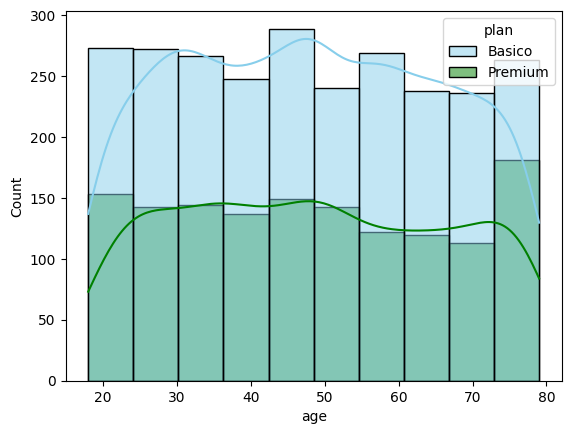

In [92]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10,palette=['skyblue','green'],kde=True)
plt.show()

💡Insights: 
- La distribucion de la variable age se observa relativamente uniforme entre los 18 y 79 años. La media (48.14) y la mediana (48) son prácticamente iguales, lo que sugiere una distribución equilibrada y sin sesgos significativos. Además, no se observan valores atípicos evidentes ni concentraciones excesivas en un grupo de edad específico.

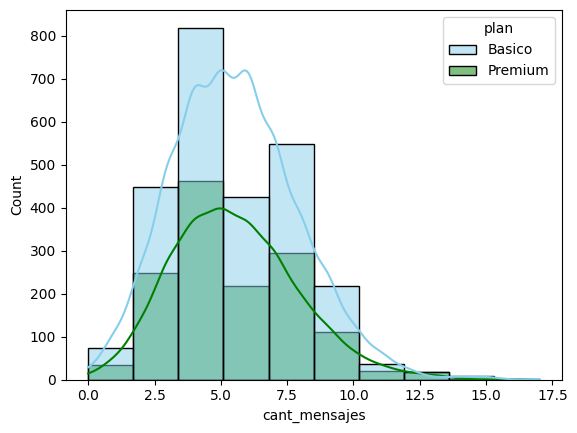

In [93]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes',hue='plan',bins=10, palette=['skyblue','green'],kde=True)
plt.show()

💡Insights: 
- Al segmentar la distribución de cant_mensajes por tipo de plan, se observa que los usuarios de los planes Básico y Premium presentan patrones de uso muy similares. En ambos casos, la mayor concentración de usuarios se encuentra entre 4 y 7 mensajes enviados. Aunque el plan Básico muestra una frecuencia absoluta mayor, esto parece estar asociado a que representa una mayor proporción de la base de usuarios. Visualmente no se aprecia una diferencia significativa en el comportamiento de mensajería entre ambos planes.

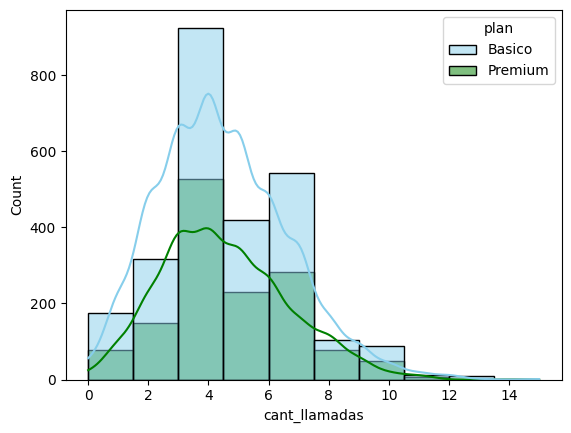

In [94]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.show()

💡Insights: 
- Analizando la variable cant_llamadas podemos observar una distribucion ligeramente sesgada a la derecha, donde la mayoria de los usuarios realiza entre 3 y 6 llamadas. Al segmentar por tipo de plan no se nota una diferencia de comportamiento entre los usuarios premium o basicos al momento de realizar llamadas. Al menos con estos datos no podemos inferir que el numero de llamdas es un diferenciador entre ambos planes. 

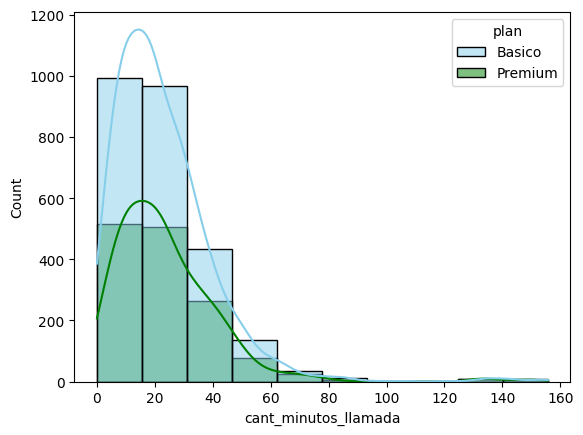

In [95]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',bins=10, palette=['skyblue','green'], kde=True)
plt.show()

💡Insights: 
- La mayoria de los usuarios acumulan menos de 30 minutos de llamadas, sin embargo en esta variable observamos que hay mayor dispersion de los datos, presentando un sesgo fuertemente marcado hacia la derecha. Esto nos lo confirma una media (23.32) mas alta que la mediana (19.78) y observamos que existen posibles usuarios de alto consumo que elevan el promedio general. Al segmentar por tipo de plan, no se observan diferencias visuales significativas en la distribucion del consumo, por lo que seria recomendable comparar medias y medianas por plan para determinar si existe una diferencia real entre usuarios basico y premium. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

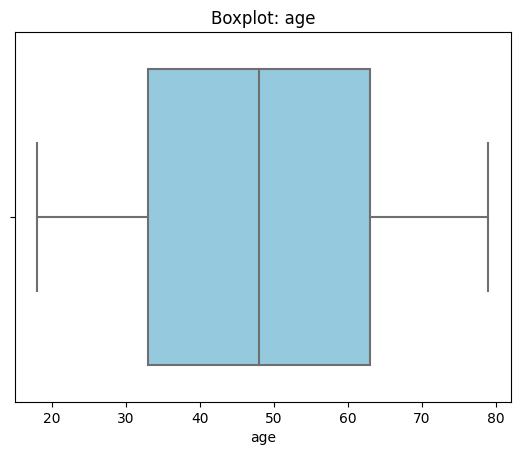

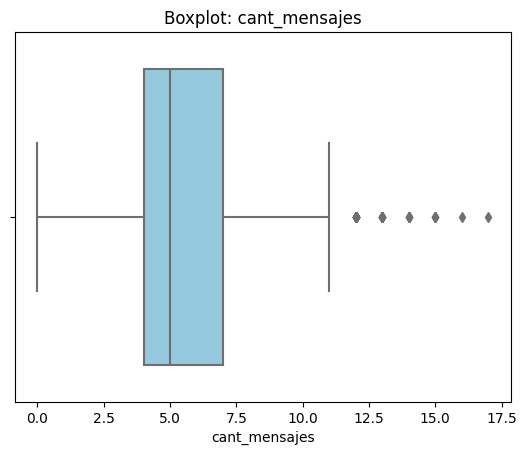

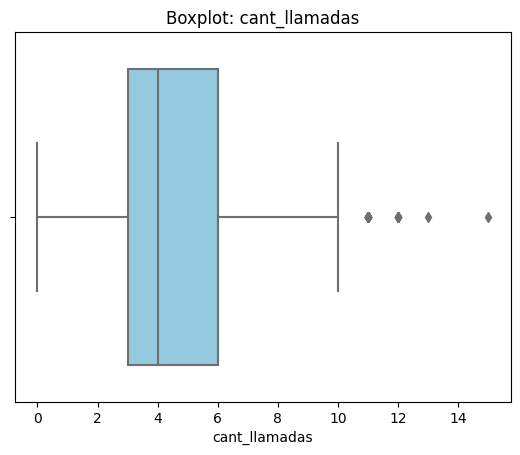

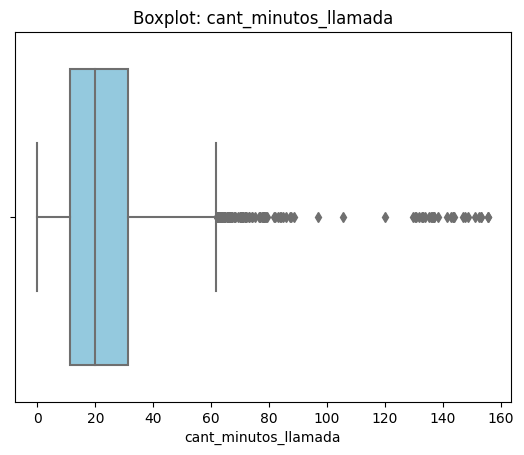

In [96]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()
    
    

💡Insights: 
- Age: No presenta outliers, la distribucion es bastante simetrica y la dispersion se mantiene estable.
- cant_mensajes: Si existen outliers, observan algunos usuarios con una cantidad superior al comportamiento tipico
- cant_llamadas: Hay presencia de outliers, aunque la distribucion de las llamadas es estable pero existen pocos usuarios con un alto consumo. 
- cant_minutos_llamada: Se identificas usuarios de alto consumo que elevan la dispersion de la variable.

In [97]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    limite_superior = Q3 + 1.5*IQR
    print(f'{col}: {limite_superior}')
    
    



cant_mensajes: 11.5
cant_llamadas: 10.5
cant_minutos_llamada: 61.870000000000005


In [98]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round(2)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,4000.00,4000.00
mean,5.52,4.48,23.31
std,2.36,2.15,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.11
50%,5.00,4.00,19.78
75%,7.00,6.00,31.41
max,17.00,15.00,155.69


💡Insights: 
- cant_mensajes: Mantener los outiers, representan usuarios reales que tienen una actividad alta de mensajes y no valores imposibles. 
- cant_llamadas: Mantener outliers, hay usuarios que alcanzan hasta 17 llamadas. Estos valores corresponden a datos de uso reales. 
- cant_minutos_llamada: Mantener outliers, se observan usuarios con hasta 155 minutos de llamada. Estos valores parecen corresponder a patrones reales de alto consumo. Por ello se deben conservar para el analisis posterior. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [99]:
# Crear columna grupo_uso
condiciones = [(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
               (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)]
opciones = ['Bajo uso','Uso medio']
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso') 

In [100]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [101]:
# Crear columna grupo_edad
condiciones =[(user_profile['age']< 30),(user_profile['age']< 60)] 
opciones = ['Joven','Adulto']
user_profile['grupo_edad'] = np.select(condiciones,opciones,default='Adulto Mayor')

In [102]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

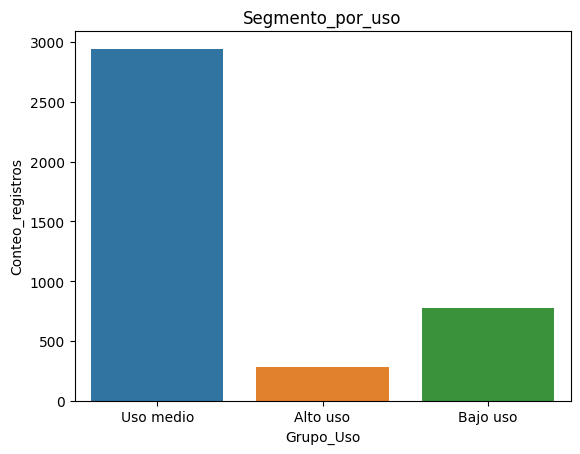

In [104]:
# Visualización de los segmentos por uso
sns.countplot( data=user_profile, x='grupo_uso')
plt.title('Segmento_por_uso')
plt.xlabel('Grupo_Uso')
plt.ylabel('Conteo_registros')
plt.show()

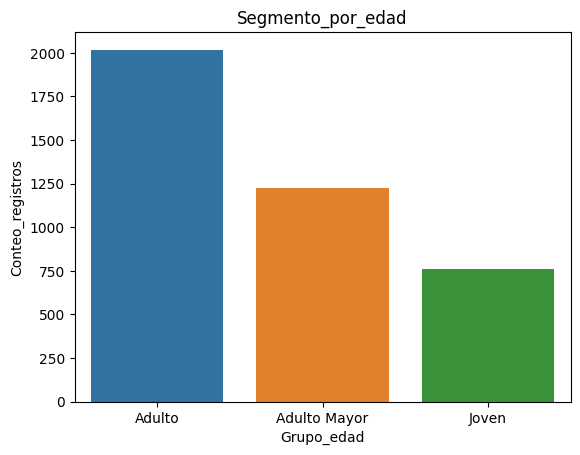

In [105]:
# Visualización de los segmentos por edad
sns.countplot( data=user_profile, x='grupo_edad')
plt.title('Segmento_por_edad')
plt.xlabel('Grupo_edad')
plt.ylabel('Conteo_registros')
plt.show()

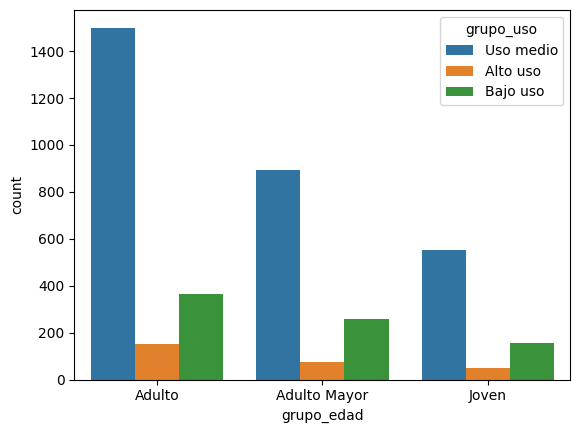

In [106]:
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='grupo_uso'
)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identico un valor sentinel (-999) en la coluna age, correspondiente a edades desconocidas. Este valor fue reemplazado por la mediana de la sdistribucion para evitar distorsiones estadisticas. 
- La columna city presento 469 valores faltantes (11.7% de los usuarios), lo que puede afectar el analisis geografico y segmentacion por ubicacion.
- Se detectaron 40 registros con fechas de registro en 2026 dentro de reg_date, fuera del rango orincioal de analisis (2024), por lo que fueron catalogadas como anomalias temporales.
- Un usuario (user_id=11082) no presento actividad registrada en llamadas ni mensajes. Tras validacion, se confirmo que no existian registros asociados en la tabla usage, por lo que sus metricas fueron interpretadas como ausencia de actividad.

🔍 **Segmentos por Edad**
- Los adultos constituyen el grupo mas representativo de la base de usuarios.
- Los adultos mayores representan una proporcion importante dentro del mercado y muestran potencial como segmento estrategico.
- Los jovenes son el grupo menos numeros dentro de la muestra analizada.


📊 **Segmentos por Nivel de Uso**
- La mayoria de los usuarios pertenece al segmento de uso medio, indicando un comportamiento relativamente estable.
- El segmento de alto uso es reducido, pero concentra los mayores niveles de actividad en mensajes, llamadas y minutos consumidos. 
- El segmento de bajo uso representa una oportunidad para desarrollar estrategias de activacion y aumentar el consumo de servicios.


➡️ Esto sugiere que la base de clientes esta compuesta principalmente por usuarios de consumo moderado, con un grupo pequeno pero valioso de usarios intesivos.
    **Segmentos mas valiosos para ConnectaTel
    Los usuarios de alto uso representan el segmento mas valioso, ya que generan un mayor consumo de servicios y potencialmente mayores ingresos. 
    Los usuarios que acumulan mas minutos de llamada son especialmente relevantes, ya que presentan patrones de uso diferenciados y podrian beneficiarse de ofertas especificas. 
    Los adultos y adultos mayores concentran la mayor parte de la base de clientes, por lo que cualquier estrategia comercial tendria mayor impacto sobre estos segmentos.

    Patrones de uso extremo(outliers)
    - Se identificaron usuarios con hasta 17 mensajes, 15 llamadas y mas de 150 minutos de llamada durante el periodo analizado.
    - Estos valores fueron conservados porque representan comportamientos reales y nio errores de captura.
    - Los usuarios de alto consumo constituyen un segmento interesante para programas de fidelizacion, planes premium o beneficios exclusivos.

    

💡 **Recomendaciones**
- Diseñar ofertas especificas para usuarios de alto uso, incorporando mayores beneficios en llamadas y mensajerias.
- Implementar campañas de activacion para suarios de bajo uso con el objetivo de incrementar su consumo.
- Analizar la relacion entre plan contratado y nivel de uso para identificar oportunidades de migracion hacia planes de mayor valor.
- Mejorar la calidad de los datos geograficos reduciendo los valores faltantes en la columna city.
- Realizar un seguimiento especifico de los usuarios de alto consumo para evaluar oportunidades de retencion y fidelizacion.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`